# Trabalho prático I — RNA e Lógica Fuzzy

Este notebook contém **somente a preparação dos dados**. Ao final, estarão disponíveis:


## 1. Bibliotecas

In [62]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

SEMENTE = 42
np.random.seed(SEMENTE)

## 2. Carregamento da base

Coloque o arquivo `dados_sinteticos_neuro_fuzzy_10000.xlsx` na mesma pasta do notebook.

In [63]:
NOME_ARQUIVO = "dados_sinteticos_neuro_fuzzy_10000.xlsx"

candidatos = [
    Path(NOME_ARQUIVO),
    Path("upload") / NOME_ARQUIVO,
]
caminho = next((p for p in candidatos if p.exists()), None)

if caminho is None:
    try:
        from google.colab import files

        print("Selecione a planilha fornecida pela professora.")
        arquivos = files.upload()
        caminho = Path(next(iter(arquivos)))
    except ImportError as erro:
        raise FileNotFoundError(
            f"Arquivo não encontrado. Coloque '{NOME_ARQUIVO}' na mesma pasta do notebook."
        ) from erro

dados = pd.read_excel(caminho, sheet_name="Dados")
print(f"Arquivo carregado: {caminho}")
print(f"Dimensões da base: {dados.shape[0]} linhas e {dados.shape[1]} colunas")
dados.head()

Arquivo carregado: dados_sinteticos_neuro_fuzzy_10000.xlsx
Dimensões da base: 10000 linhas e 13 colunas


,id,temperatura_c,latencia_ms,perda_pacotes_pct,tensao_v,rotacao_rpm,reinicializacoes_h,alarme_rede,alarme_temperatura,alarme_tensao,sensor_ausente,cenario,classe
0,LAB-02364,47.4,25.9,0.0,217.4,2069.0,2.0,1,0,0,0,tipico,alimentacao
1,LAB-00354,39.0,127.7,2.5,217.1,2649.0,0.0,1,0,0,0,fronteira,rede
2,LAB-09096,34.9,65.8,2.5,239.0,1798.0,6.0,0,0,1,0,tipico,alimentacao
3,LAB-09628,54.1,71.3,6.1,200.3,2235.0,4.0,0,0,1,0,tipico,alimentacao
4,LAB-03324,53.9,25.9,3.0,237.6,2156.0,1.0,0,0,0,0,tipico,alimentacao


## 3. Conferência inicial

As células abaixo permitem verificar os tipos das colunas, os valores ausentes e a distribuição das classes.

In [64]:
resumo_colunas = pd.DataFrame(
    {
        "tipo": dados.dtypes.astype(str),
        "ausentes": dados.isna().sum(),
        "valores_unicos": dados.nunique(dropna=True),
    }
)
resumo_colunas

,tipo,ausentes,valores_unicos
id,str,0,10000
temperatura_c,float64,118,752
latencia_ms,float64,117,2366
perda_pacotes_pct,float64,118,598
tensao_v,float64,114,659
rotacao_rpm,float64,125,3209
reinicializacoes_h,float64,125,11
alarme_rede,int64,0,2
alarme_temperatura,int64,0,2
alarme_tensao,int64,0,2


,quantidade
classe,
alimentacao,2500
normal,2500
rede,2500
refrigeracao,2500


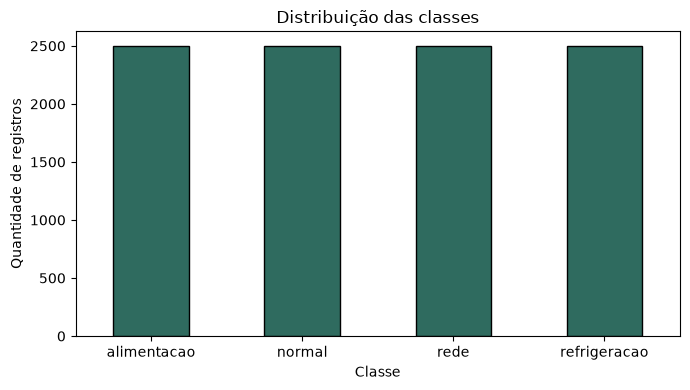

In [65]:
distribuicao_classes = dados["classe"].value_counts().sort_index()
display(distribuicao_classes.to_frame("quantidade"))

distribuicao_classes.plot(
    kind="bar", color="#2F6B5F", edgecolor="black", figsize=(7, 4)
)
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Separação das variáveis

Serão utilizadas como entradas as seis medições e os três alarmes descritos no trabalho. As colunas `id`, `cenario` e `sensor_ausente` serão preservadas apenas para identificar e analisar posteriormente os resultados; `classe` será a variável-alvo. Assim, informações sobre a forma como o exemplo foi produzido não entram no modelo.

In [66]:
COLUNAS_NUMERICAS = [
    "temperatura_c",
    "latencia_ms",
    "perda_pacotes_pct",
    "tensao_v",
    "rotacao_rpm",
    "reinicializacoes_h",
]

COLUNAS_BINARIAS = [
    "alarme_rede",
    "alarme_temperatura",
    "alarme_tensao",
]

COLUNAS_ENTRADA = COLUNAS_NUMERICAS + COLUNAS_BINARIAS
COLUNAS_AUXILIARES = ["id", "cenario", "sensor_ausente"]

X = dados[COLUNAS_ENTRADA].copy()
y = dados["classe"].copy()
auxiliares = dados[COLUNAS_AUXILIARES].copy()

print("Variáveis de entrada:", COLUNAS_ENTRADA)
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Variáveis de entrada: ['temperatura_c', 'latencia_ms', 'perda_pacotes_pct', 'tensao_v', 'rotacao_rpm', 'reinicializacoes_h', 'alarme_rede', 'alarme_temperatura', 'alarme_tensao']
Formato de X: (10000, 9)
Formato de y: (10000,)


## 5. Divisão em treino e teste

A divisão abaixo reserva 80% dos registros para treino e 20% para teste. O parâmetro `stratify=y` mantém a proporção das quatro classes nos dois conjuntos. Os índices também são divididos para que `id`, `cenario` e `sensor_ausente` possam ser usados na análise dos erros sem participar da aprendizagem.

In [67]:
indices = np.arange(len(dados))

idx_treino, idx_teste = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEMENTE,
    stratify=y,
)

X_treino = X.iloc[idx_treino].copy()
X_teste = X.iloc[idx_teste].copy()
y_treino = y.iloc[idx_treino].copy()
y_teste = y.iloc[idx_teste].copy()
aux_treino = auxiliares.iloc[idx_treino].copy()
aux_teste = auxiliares.iloc[idx_teste].copy()

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)
print("\nProporção das classes no treino:")
display(
    y_treino.value_counts(normalize=True).sort_index().to_frame("proporção")
)
print("Proporção das classes no teste:")
display(
    y_teste.value_counts(normalize=True).sort_index().to_frame("proporção")
)

Treino: (8000, 9) | Teste: (2000, 9)

Proporção das classes no treino:


,proporção
classe,
alimentacao,0.25
normal,0.25
rede,0.25
refrigeracao,0.25


Proporção das classes no teste:


,proporção
classe,
alimentacao,0.25
normal,0.25
rede,0.25
refrigeracao,0.25


## 6. Preparação para a RNA

Nos dados numéricos, os valores ausentes serão substituídos pela mediana calculada **somente no treino**. Em seguida, essas variáveis serão padronizadas. As colunas binárias já estão na escala 0–1 e serão apenas copiadas. O mesmo transformador ajustado no treino será aplicado ao teste, evitando vazamento de dados.

In [68]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputacao", SimpleImputer(strategy="median")),
        ("padronizacao", StandardScaler()),
    ]
)

preparador_rna = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, COLUNAS_NUMERICAS),
        ("binarias", "passthrough", COLUNAS_BINARIAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_treino_rna = preparador_rna.fit_transform(X_treino)
X_teste_rna = preparador_rna.transform(X_teste)

codificador_classes = LabelEncoder()
y_treino_cod = codificador_classes.fit_transform(y_treino)
y_teste_cod = codificador_classes.transform(y_teste)

nomes_entradas_rna = preparador_rna.get_feature_names_out().tolist()
nomes_classes = codificador_classes.classes_.tolist()

print("Formato dos dados da RNA:")
print("X_treino_rna:", X_treino_rna.shape)
print("X_teste_rna: ", X_teste_rna.shape)
print("Ordem das classes:", dict(enumerate(nomes_classes)))

Formato dos dados da RNA:
X_treino_rna: (8000, 9)
X_teste_rna:  (2000, 9)
Ordem das classes: {0: 'alimentacao', 1: 'normal', 2: 'rede', 3: 'refrigeracao'}


In [69]:
# Verificações simples da preparação
assert X_treino_rna.shape == (8000, 9)
assert X_teste_rna.shape == (2000, 9)
assert not np.isnan(X_treino_rna).any()
assert not np.isnan(X_teste_rna).any()
assert len(nomes_classes) == 4
print("Sem valores ausentes.")

Sem valores ausentes.


### A partir daqui, a equipe deverá construir a RNA

Utilize `X_treino_rna` e `y_treino_cod` para o treinamento. Use `X_teste_rna` e `y_teste_cod` apenas na avaliação final. A arquitetura solicitada possui duas camadas ocultas, com 32 e 16 neurônios, ativação ReLU e quatro saídas com softmax.

Acurácia:   0.9085
Precisão:   0.9087
Revocação:  0.9085
Macro-F1:   0.9084

              precision    recall  f1-score   support

 alimentacao       0.89      0.91      0.90       500
      normal       0.92      0.87      0.89       500
        rede       0.92      0.92      0.92       500
refrigeracao       0.92      0.93      0.92       500

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



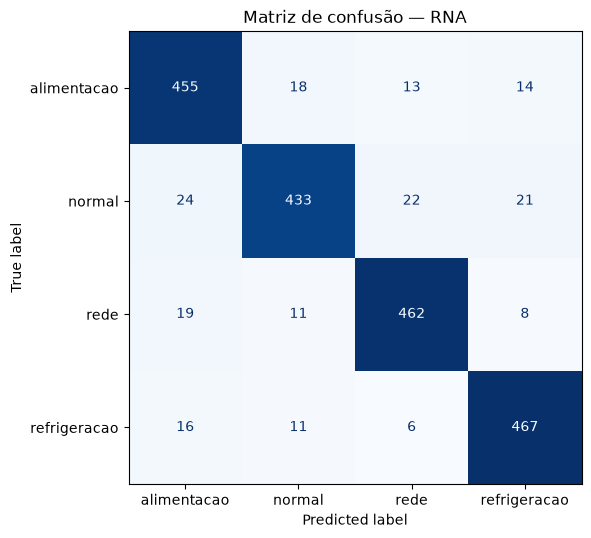

In [70]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

rna = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=SEMENTE,
)

rna.fit(X_treino_rna, y_treino_cod)

y_pred_cod = rna.predict(X_teste_rna)

acuracia = accuracy_score(y_teste_cod, y_pred_cod)
precisao = precision_score(y_teste_cod, y_pred_cod, average="macro")
revocacao = recall_score(y_teste_cod, y_pred_cod, average="macro")
macro_f1 = f1_score(y_teste_cod, y_pred_cod, average="macro")

print(f"Acurácia:   {acuracia:.4f}")
print(f"Precisão:   {precisao:.4f}")
print(f"Revocação:  {revocacao:.4f}")
print(f"Macro-F1:   {macro_f1:.4f}")
print()
print(
    classification_report(y_teste_cod, y_pred_cod, target_names=nomes_classes)
)

matriz_confusao = confusion_matrix(y_teste_cod, y_pred_cod)
disp = ConfusionMatrixDisplay(matriz_confusao, display_labels=nomes_classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão — RNA")
plt.tight_layout()
plt.show()


## 7. Preparação para o sistema fuzzy

Para o sistema fuzzy, as variáveis devem continuar em suas unidades originais, pois os limites das funções de pertinência serão definidos em °C, ms, %, V, rpm e quantidade de reinicializações. Por isso, será feita somente a imputação pela mediana do treino, sem padronização.

In [71]:
imputador_fuzzy = SimpleImputer(strategy="median")

X_treino_fuzzy = X_treino.copy()
X_teste_fuzzy = X_teste.copy()

X_treino_fuzzy[COLUNAS_NUMERICAS] = imputador_fuzzy.fit_transform(
    X_treino[COLUNAS_NUMERICAS]
)
X_teste_fuzzy[COLUNAS_NUMERICAS] = imputador_fuzzy.transform(
    X_teste[COLUNAS_NUMERICAS]
)

assert not X_treino_fuzzy.isna().any().any()
assert not X_teste_fuzzy.isna().any().any()

print("Dados fuzzy preparados nas unidades originais.")
X_treino_fuzzy.head()

Dados fuzzy preparados nas unidades originais.


,temperatura_c,latencia_ms,perda_pacotes_pct,tensao_v,rotacao_rpm,reinicializacoes_h,alarme_rede,alarme_temperatura,alarme_tensao
3542,49.1,99.0,9.2,218.2,2392.0,1.0,1,0,0
6094,36.4,25.9,4.8,209.4,2137.0,1.0,0,0,0
6585,67.1,57.6,9.1,196.3,1672.0,4.0,0,0,1
7859,56.9,46.9,4.1,218.0,2240.0,1.0,0,0,0
9983,53.5,15.0,0.0,202.9,2716.0,2.0,0,0,1


### A partir daqui, a equipe deverá construir o sistema fuzzy

A equipe deverá:

1. definir e representar graficamente as funções de pertinência;
2. construir os módulos de rede, refrigeração e alimentação;
3. elaborar pelo menos quatro regras para cada módulo;

#### 1. Funções de pertinência e fuzzificação

Os limites abaixo partem das faixas sugeridas na Tabela 3 do enunciado e foram conferidos contra os valores observados na base. Funções trapezoidais são usadas nos extremos para representar regiões estáveis e funções triangulares representam os estados intermediários. As sobreposições são intencionais: um valor de fronteira pode pertencer parcialmente a dois termos linguísticos, evitando mudanças bruscas no diagnóstico.

Além dos gráficos, a célula transforma cada uma das seis medições em três graus de pertinência no intervalo $[0, 1]$. Assim, cada registro passa a possuir 18 características fuzzy. Os alarmes binários permanecem disponíveis como evidências adicionais para as regras dos módulos, conforme permitido pelo enunciado.

,variavel,termo,funcao,parametros
0,temperatura_c,normal,trapezoidal,"(20.0, 20.0, 45.0, 55.0)"
1,temperatura_c,alta,triangular,"(45.0, 65.0, 80.0)"
2,temperatura_c,critica,trapezoidal,"(70.0, 80.0, 100.0, 100.0)"
3,latencia_ms,baixa,trapezoidal,"(1.0, 1.0, 30.0, 60.0)"
4,latencia_ms,moderada,triangular,"(40.0, 100.0, 160.0)"
5,latencia_ms,alta,trapezoidal,"(120.0, 200.0, 500.0, 500.0)"
6,perda_pacotes_pct,pequena,trapezoidal,"(0.0, 0.0, 2.0, 5.0)"
7,perda_pacotes_pct,media,triangular,"(2.0, 12.0, 25.0)"
8,perda_pacotes_pct,severa,trapezoidal,"(15.0, 30.0, 100.0, 100.0)"
9,tensao_v,baixa,trapezoidal,"(180.0, 180.0, 200.0, 210.0)"


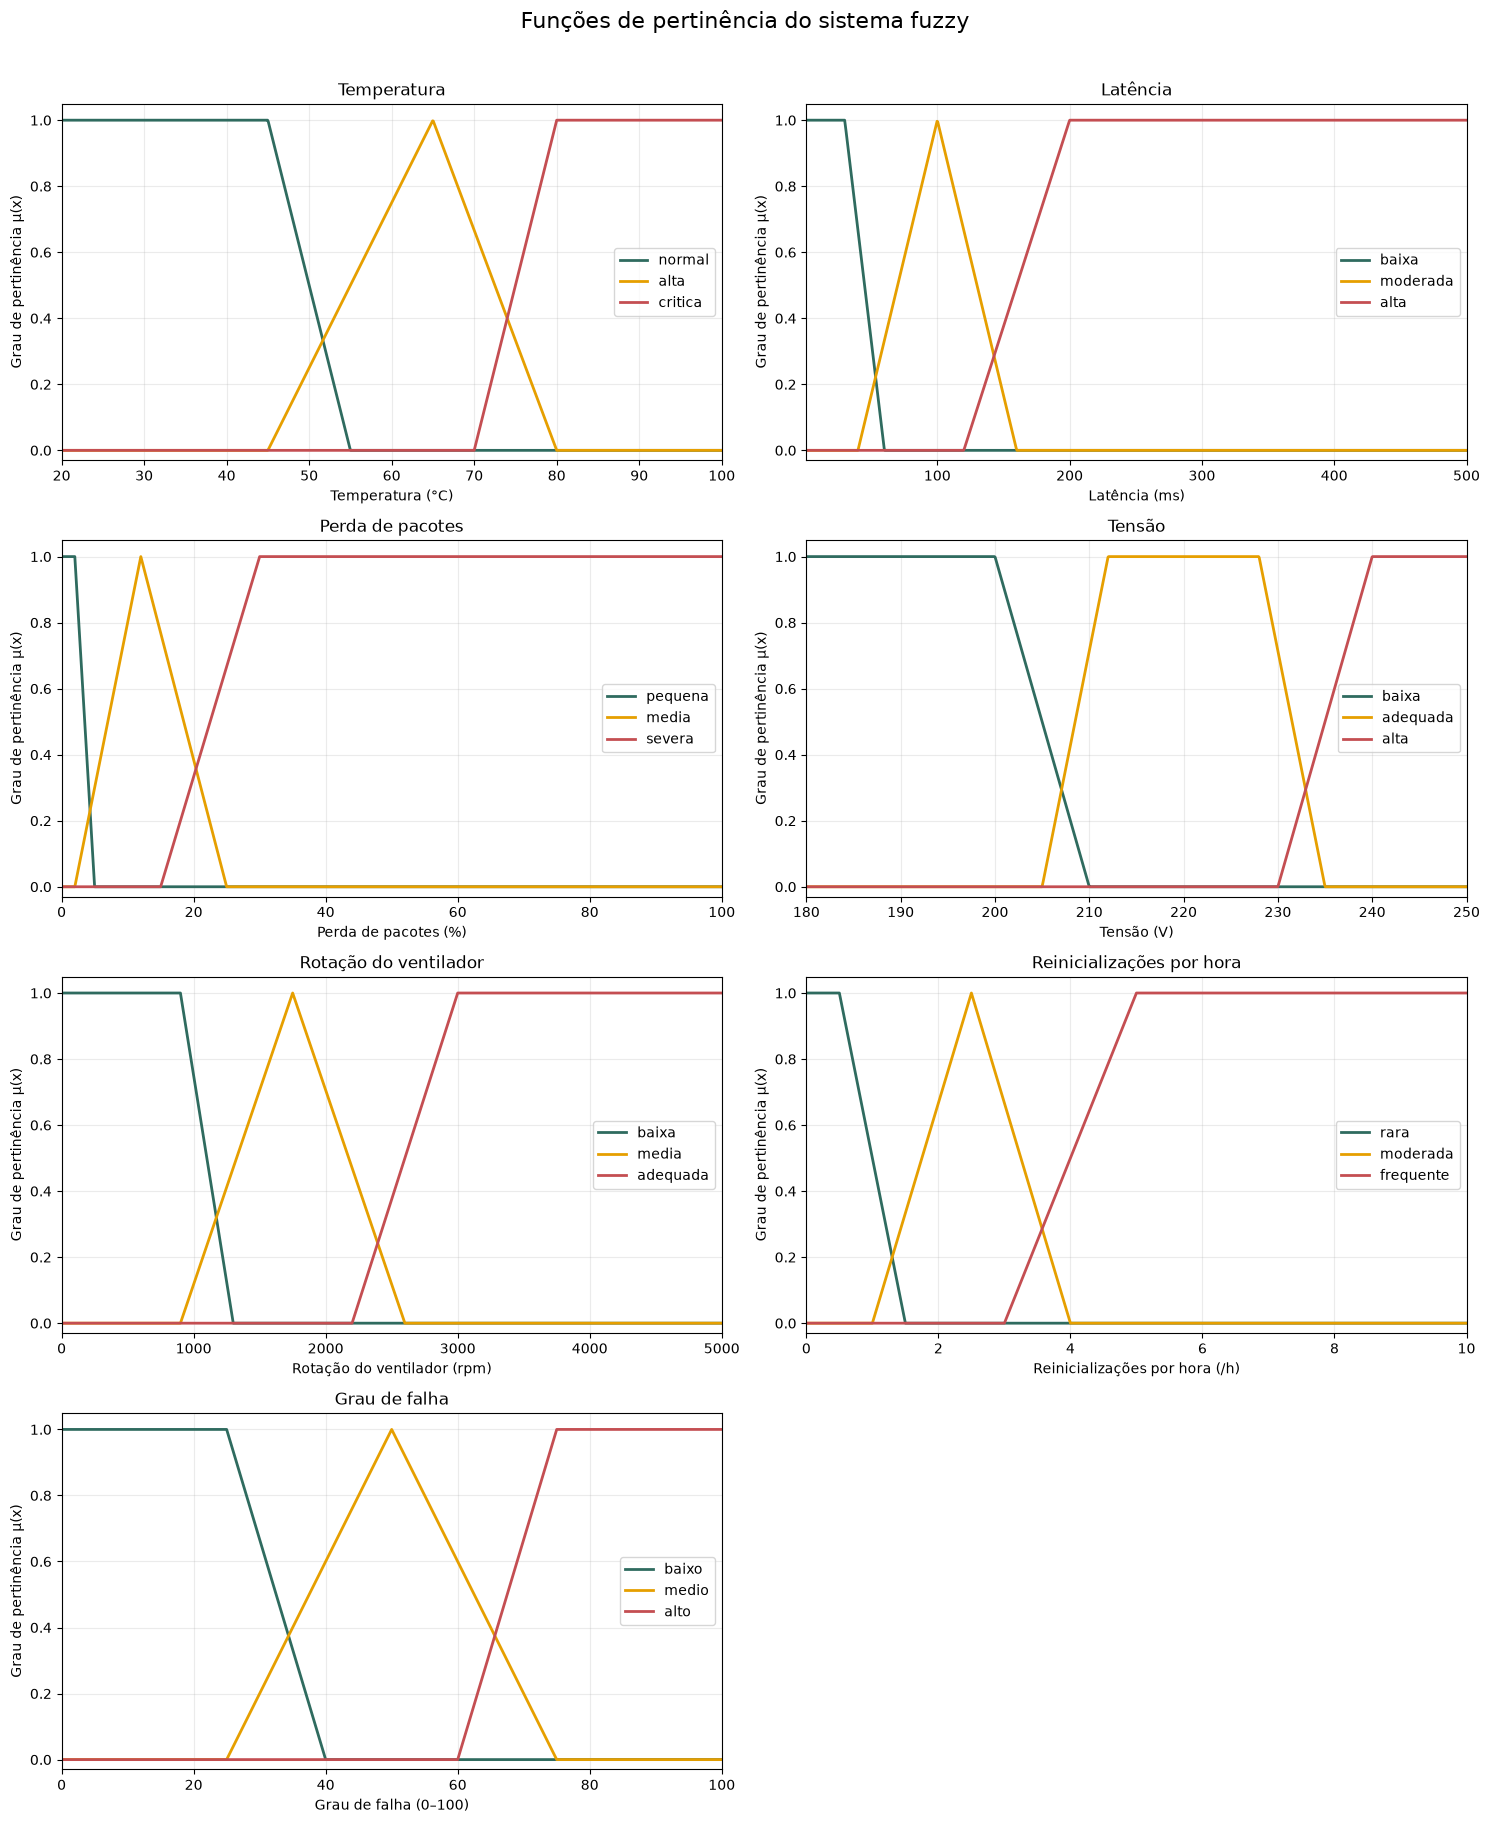

Treino fuzzificado: (8000, 18)
Teste fuzzificado:  (2000, 18)


,temperatura_c,latencia_ms,perda_pacotes_pct,tensao_v,rotacao_rpm,reinicializacoes_h,temperatura_c__normal,temperatura_c__alta,temperatura_c__critica,latencia_ms__baixa,...,perda_pacotes_pct__severa,tensao_v__baixa,tensao_v__adequada,tensao_v__alta,rotacao_rpm__baixa,rotacao_rpm__media,rotacao_rpm__adequada,reinicializacoes_h__rara,reinicializacoes_h__moderada,reinicializacoes_h__frequente
3542,49.1,99.0,9.2,218.2,2392.0,1.0,0.59,0.205,0.0,0.00,...,0.0,0.00,1.000000,0.0,0.0,0.244706,0.24,0.5,0.0,0.0
6094,36.4,25.9,4.8,209.4,2137.0,1.0,1.00,0.000,0.0,1.00,...,0.0,0.06,0.628571,0.0,0.0,0.544706,0.00,0.5,0.0,0.0
6585,67.1,57.6,9.1,196.3,1672.0,4.0,0.00,0.860,0.0,0.08,...,0.0,1.00,0.000000,0.0,0.0,0.908235,0.00,0.0,0.0,0.5


In [72]:
# Funções de pertinência implementadas diretamente com NumPy.
# Isso deixa explícito como cada grau é calculado e evita dependências adicionais.
def pertinencia_triangular(x, a, b, c):
    """Calcula a função de pertinência triangular definida por (a, b, c)."""
    if not a < b < c:
        raise ValueError(
            "Os parâmetros triangulares devem satisfazer a < b < c."
        )

    x = np.asarray(x, dtype=float)
    subida = (x - a) / (b - a)
    descida = (c - x) / (c - b)
    return np.clip(np.minimum(subida, descida), 0.0, 1.0)


def pertinencia_trapezoidal(x, a, b, c, d):
    """Calcula a função trapezoidal, incluindo ombros com a=b ou c=d."""
    if not a <= b <= c <= d or a == d:
        raise ValueError(
            "Os parâmetros trapezoidais devem satisfazer a <= b <= c <= d."
        )

    x = np.asarray(x, dtype=float)
    graus = np.zeros_like(x)

    if a == b:  # ombro esquerdo
        graus[x <= b] = 1.0
    else:
        mascara_subida = (x > a) & (x < b)
        graus[mascara_subida] = (x[mascara_subida] - a) / (b - a)

    graus[(x >= b) & (x <= c)] = 1.0

    if c == d:  # ombro direito
        graus[x >= c] = 1.0
    else:
        mascara_descida = (x > c) & (x < d)
        graus[mascara_descida] = (d - x[mascara_descida]) / (d - c)

    return np.clip(graus, 0.0, 1.0)


from typing import Annotated, Literal, Union

from pydantic import BaseModel, ConfigDict, Field, model_validator


class FuncaoPertinenciaBase(BaseModel):
    """Base imutável para as funções de pertinência: nenhum campo muda após a criação."""

    model_config = ConfigDict(frozen=True)


class FuncaoTriangular(FuncaoPertinenciaBase):
    """Função triangular com vértices a < b < c."""

    tipo: Literal["tri"] = "tri"
    a: float
    b: float
    c: float

    @model_validator(mode="after")
    def validar_ordem(self) -> "FuncaoTriangular":
        if not self.a < self.b < self.c:
            raise ValueError("Função triangular exige a < b < c.")
        return self

    @property
    def parametros(self) -> tuple[float, float, float]:
        return (self.a, self.b, self.c)


class FuncaoTrapezoidal(FuncaoPertinenciaBase):
    """Função trapezoidal com vértices a <= b <= c <= d (ombros quando a=b ou c=d)."""

    tipo: Literal["trap"] = "trap"
    a: float
    b: float
    c: float
    d: float

    @model_validator(mode="after")
    def validar_ordem(self) -> "FuncaoTrapezoidal":
        if not self.a <= self.b <= self.c <= self.d or self.a == self.d:
            raise ValueError(
                "Função trapezoidal exige a <= b <= c <= d, com a != d."
            )
        return self

    @property
    def parametros(self) -> tuple[float, float, float, float]:
        return (self.a, self.b, self.c, self.d)


# União discriminada pelo campo "tipo": o pydantic escolhe a subclasse correta
# e rejeita qualquer combinação de campos que não corresponda a uma das duas formas.
FuncaoPertinencia = Annotated[
    Union[FuncaoTriangular, FuncaoTrapezoidal], Field(discriminator="tipo")
]


class TermoLinguistico(BaseModel):
    """Um termo linguístico nomeado (ex.: "alta") associado à sua função de pertinência."""

    model_config = ConfigDict(frozen=True)

    nome: str
    funcao: FuncaoPertinencia


class VariavelPertinencia(BaseModel):
    """Configuração fuzzy completa de uma variável de entrada ou saída."""

    model_config = ConfigDict(frozen=True)

    variavel: str
    rotulo: str
    unidade: str
    universo_min: float
    universo_max: float
    termos: tuple[TermoLinguistico, ...]

    @model_validator(mode="after")
    def validar_universo_e_termos(self) -> "VariavelPertinencia":
        if not self.universo_min < self.universo_max:
            raise ValueError("universo_min deve ser menor que universo_max.")
        if len(self.termos) == 0:
            raise ValueError(
                f"{self.variavel}: é necessário ao menos um termo linguístico."
            )
        nomes = [termo.nome for termo in self.termos]
        if len(nomes) != len(set(nomes)):
            raise ValueError(
                f"{self.variavel}: nomes de termos duplicados: {nomes}."
            )
        return self

    @property
    def universo(self) -> tuple[float, float]:
        return (self.universo_min, self.universo_max)


class ConfiguracaoFuzzy(BaseModel):
    """Registro imutável de todas as variáveis fuzzy do sistema, indexado pelo nome da coluna."""

    model_config = ConfigDict(frozen=True)

    variaveis: dict[str, VariavelPertinencia]

    @model_validator(mode="after")
    def validar_chaves(self) -> "ConfiguracaoFuzzy":
        for chave, variavel in self.variaveis.items():
            if chave != variavel.variavel:
                raise ValueError(
                    f"Chave '{chave}' não corresponde ao campo variavel='{variavel.variavel}'."
                )
        return self

    def __getitem__(self, chave: str) -> VariavelPertinencia:
        return self.variaveis[chave]

    def __iter__(self):
        return iter(self.variaveis)

    def __len__(self) -> int:
        return len(self.variaveis)

    def items(self):
        return self.variaveis.items()


# Os limites partem da Tabela 3 do enunciado e respeitam as faixas da base.
# Funções trapezoidais são usadas nos extremos para representar regiões estáveis
# e funções triangulares representam os estados intermediários.
CONFIG_PERTINENCIA = ConfiguracaoFuzzy(
    variaveis={
        "temperatura_c": VariavelPertinencia(
            variavel="temperatura_c",
            rotulo="Temperatura",
            unidade="°C",
            universo_min=20,
            universo_max=100,
            termos=(
                TermoLinguistico(
                    nome="normal",
                    funcao=FuncaoTrapezoidal(a=20, b=20, c=45, d=55),
                ),
                TermoLinguistico(
                    nome="alta", funcao=FuncaoTriangular(a=45, b=65, c=80)
                ),
                TermoLinguistico(
                    nome="critica",
                    funcao=FuncaoTrapezoidal(a=70, b=80, c=100, d=100),
                ),
            ),
        ),
        "latencia_ms": VariavelPertinencia(
            variavel="latencia_ms",
            rotulo="Latência",
            unidade="ms",
            universo_min=1,
            universo_max=500,
            termos=(
                TermoLinguistico(
                    nome="baixa",
                    funcao=FuncaoTrapezoidal(a=1, b=1, c=30, d=60),
                ),
                TermoLinguistico(
                    nome="moderada",
                    funcao=FuncaoTriangular(a=40, b=100, c=160),
                ),
                TermoLinguistico(
                    nome="alta",
                    funcao=FuncaoTrapezoidal(a=120, b=200, c=500, d=500),
                ),
            ),
        ),
        "perda_pacotes_pct": VariavelPertinencia(
            variavel="perda_pacotes_pct",
            rotulo="Perda de pacotes",
            unidade="%",
            universo_min=0,
            universo_max=100,
            termos=(
                TermoLinguistico(
                    nome="pequena",
                    funcao=FuncaoTrapezoidal(a=0, b=0, c=2, d=5),
                ),
                TermoLinguistico(
                    nome="media", funcao=FuncaoTriangular(a=2, b=12, c=25)
                ),
                TermoLinguistico(
                    nome="severa",
                    funcao=FuncaoTrapezoidal(a=15, b=30, c=100, d=100),
                ),
            ),
        ),
        "tensao_v": VariavelPertinencia(
            variavel="tensao_v",
            rotulo="Tensão",
            unidade="V",
            universo_min=180,
            universo_max=250,
            termos=(
                TermoLinguistico(
                    nome="baixa",
                    funcao=FuncaoTrapezoidal(a=180, b=180, c=200, d=210),
                ),
                TermoLinguistico(
                    nome="adequada",
                    funcao=FuncaoTrapezoidal(a=205, b=212, c=228, d=235),
                ),
                TermoLinguistico(
                    nome="alta",
                    funcao=FuncaoTrapezoidal(a=230, b=240, c=250, d=250),
                ),
            ),
        ),
        "rotacao_rpm": VariavelPertinencia(
            variavel="rotacao_rpm",
            rotulo="Rotação do ventilador",
            unidade="rpm",
            universo_min=0,
            universo_max=5000,
            termos=(
                TermoLinguistico(
                    nome="baixa",
                    funcao=FuncaoTrapezoidal(a=0, b=0, c=900, d=1300),
                ),
                TermoLinguistico(
                    nome="media",
                    funcao=FuncaoTriangular(a=900, b=1750, c=2600),
                ),
                TermoLinguistico(
                    nome="adequada",
                    funcao=FuncaoTrapezoidal(a=2200, b=3000, c=5000, d=5000),
                ),
            ),
        ),
        "reinicializacoes_h": VariavelPertinencia(
            variavel="reinicializacoes_h",
            rotulo="Reinicializações por hora",
            unidade="/h",
            universo_min=0,
            universo_max=10,
            termos=(
                TermoLinguistico(
                    nome="rara",
                    funcao=FuncaoTrapezoidal(a=0, b=0, c=0.5, d=1.5),
                ),
                TermoLinguistico(
                    nome="moderada", funcao=FuncaoTriangular(a=1, b=2.5, c=4)
                ),
                TermoLinguistico(
                    nome="frequente",
                    funcao=FuncaoTrapezoidal(a=3, b=5, c=10, d=10),
                ),
            ),
        ),
        "grau_falha": VariavelPertinencia(
            variavel="grau_falha",
            rotulo="Grau de falha",
            unidade="0–100",
            universo_min=0,
            universo_max=100,
            termos=(
                TermoLinguistico(
                    nome="baixo",
                    funcao=FuncaoTrapezoidal(a=0, b=0, c=25, d=40),
                ),
                TermoLinguistico(
                    nome="medio", funcao=FuncaoTriangular(a=25, b=50, c=75)
                ),
                TermoLinguistico(
                    nome="alto",
                    funcao=FuncaoTrapezoidal(a=60, b=75, c=100, d=100),
                ),
            ),
        ),
    }
)


def calcular_pertinencia(valores, funcao: FuncaoPertinencia):
    if isinstance(funcao, FuncaoTriangular):
        return pertinencia_triangular(valores, *funcao.parametros)
    if isinstance(funcao, FuncaoTrapezoidal):
        return pertinencia_trapezoidal(valores, *funcao.parametros)
    raise TypeError(f"Tipo de função desconhecido: {type(funcao)!r}")


# Tabela auditável com todos os parâmetros adotados.
linhas_parametros = []
for variavel, configuracao in CONFIG_PERTINENCIA.items():
    for termo in configuracao.termos:
        linhas_parametros.append(
            {
                "variavel": variavel,
                "termo": termo.nome,
                "funcao": "triangular"
                if termo.funcao.tipo == "tri"
                else "trapezoidal",
                "parametros": termo.funcao.parametros,
            }
        )

tabela_parametros_pertinencia = pd.DataFrame(linhas_parametros)
display(tabela_parametros_pertinencia)


# Representação gráfica das seis entradas e da saída usada pelos módulos.
fig, eixos = plt.subplots(4, 2, figsize=(15, 18))
eixos = eixos.ravel()
cores = ["#2F6B5F", "#E69F00", "#C44E52"]

for eixo, (variavel, configuracao) in zip(eixos, CONFIG_PERTINENCIA.items()):
    inicio, fim = configuracao.universo
    universo = np.linspace(inicio, fim, 1001)

    for cor, termo in zip(cores, configuracao.termos):
        graus = calcular_pertinencia(universo, termo.funcao)
        eixo.plot(universo, graus, linewidth=2, color=cor, label=termo.nome)

    eixo.set_title(configuracao.rotulo)
    eixo.set_xlabel(f"{configuracao.rotulo} ({configuracao.unidade})")
    eixo.set_ylabel("Grau de pertinência μ(x)")
    eixo.set_xlim(inicio, fim)
    eixo.set_ylim(-0.03, 1.05)
    eixo.grid(alpha=0.25)
    eixo.legend()

for eixo in eixos[len(CONFIG_PERTINENCIA) :]:
    eixo.axis("off")

fig.suptitle("Funções de pertinência do sistema fuzzy", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


# Fuzzificação efetiva dos dados: cada medição vira três graus entre 0 e 1.
def fuzzificar_dataframe(dados_entrada):
    resultado = pd.DataFrame(index=dados_entrada.index)

    for variavel in COLUNAS_NUMERICAS:
        configuracao = CONFIG_PERTINENCIA[variavel]
        valores = dados_entrada[variavel].to_numpy(dtype=float)
        graus_da_variavel = []

        for termo in configuracao.termos:
            graus = calcular_pertinencia(valores, termo.funcao)
            resultado[f"{variavel}__{termo.nome}"] = graus
            graus_da_variavel.append(graus)

        # Toda medição válida deve ativar pelo menos um termo linguístico.
        maior_ativacao = np.max(np.column_stack(graus_da_variavel), axis=1)
        if np.any(maior_ativacao <= 0):
            raise ValueError(f"Há valores de {variavel} sem cobertura fuzzy.")

    return resultado


X_treino_fuzzificado = fuzzificar_dataframe(X_treino_fuzzy)
X_teste_fuzzificado = fuzzificar_dataframe(X_teste_fuzzy)

assert X_treino_fuzzificado.shape == (8000, 18)
assert X_teste_fuzzificado.shape == (2000, 18)
assert X_treino_fuzzificado.to_numpy().min() >= 0
assert X_treino_fuzzificado.to_numpy().max() <= 1
assert X_teste_fuzzificado.to_numpy().min() >= 0
assert X_teste_fuzzificado.to_numpy().max() <= 1

print("Treino fuzzificado:", X_treino_fuzzificado.shape)
print("Teste fuzzificado: ", X_teste_fuzzificado.shape)
display(
    pd.concat(
        [
            X_treino_fuzzy[COLUNAS_NUMERICAS].head(3),
            X_treino_fuzzificado.head(3),
        ],
        axis=1,
    )
)


#### 2. Regras fuzzy

A base possui as classes **normal**, **rede**, **refrigeração** e **alimentação**. Portanto, os sinais de temperatura são tratados nas regras de refrigeração.

##### Normal

1. **SE** temperatura é normal **E** rotação é adequada **ENTÃO** o diagnóstico é normal.
2. **SE** latência é baixa **E** perda de pacotes é pequena **ENTÃO** o diagnóstico é normal.
3. **SE** tensão é adequada **E** reinicializações são raras **ENTÃO** o diagnóstico é normal.
4. **SE** temperatura é normal **E** latência é baixa **E** tensão é adequada **ENTÃO** o diagnóstico é normal.

##### Rede

1. **SE** latência é alta **ENTÃO** o diagnóstico é falha de rede.
2. **SE** perda de pacotes é severa **ENTÃO** o diagnóstico é falha de rede.
3. **SE** latência é moderada **E** perda de pacotes é média **ENTÃO** o diagnóstico é falha de rede.
4. **SE** o alarme de rede está ativo **E** a latência não é baixa **ENTÃO** o diagnóstico é falha de rede.

##### Refrigeração

1. **SE** temperatura é crítica **ENTÃO** o diagnóstico é falha de refrigeração.
2. **SE** rotação é baixa **ENTÃO** o diagnóstico é falha de refrigeração.
3. **SE** temperatura é alta **E** rotação é baixa **ENTÃO** o diagnóstico é falha de refrigeração.
4. **SE** o alarme de temperatura está ativo **E** a temperatura não é normal **ENTÃO** o diagnóstico é falha de refrigeração.

##### Alimentação

1. **SE** tensão é baixa **ENTÃO** o diagnóstico é falha de alimentação.
2. **SE** tensão é alta **ENTÃO** o diagnóstico é falha de alimentação.
3. **SE** reinicializações são frequentes **ENTÃO** o diagnóstico é falha de alimentação.
4. **SE** o alarme de tensão está ativo **E** a tensão não é adequada **ENTÃO** o diagnóstico é falha de alimentação.

In [73]:
# PARTE DOS ALUNOS: demonstrar fuzzificação, inferência e defuzzificação.

# Seu código:

## 8. Objetos disponíveis para o trabalho

| Objeto | Uso |
|---|---|
| `X_treino_rna` | Entradas padronizadas para treinar a RNA |
| `X_teste_rna` | Entradas padronizadas para testar a RNA |
| `y_treino_cod` | Classes numéricas do treino |
| `y_teste_cod` | Classes numéricas do teste |
| `nomes_classes` | Ordem usada na codificação das classes |
| `X_treino_fuzzy` | Entradas de treino nas unidades originais |
| `X_teste_fuzzy` | Entradas de teste nas unidades originais |
| `y_treino`, `y_teste` | Classes em texto |
| `aux_treino`, `aux_teste` | ID, cenário e indicação de sensor ausente para análises |
| `preparador_rna` | Transformador ajustado no treino para preparar novos dados |
| `imputador_fuzzy` | Imputador ajustado no treino para o sistema fuzzy |